# Data-Driven Task Management Analysis


In [43]:
import pandas as pd 
import matplotlib.pyplot as plt

## Load The Task Dataset

In [44]:
df=pd.read_csv("task_data.csv")
df

,task_id,task_name,category,priority,status,assigned_to,due_date,created_date,estimated_hours,actual_hours
0,1,Design homepage UI,Design,High,In Progress,Ayesha,2026-04-10,2026-03-01,8,10.0
1,2,Fix login bug,Development,High,Pending,Rahul,2026-04-05,2026-03-10,4,NaN
2,3,Write unit tests,Testing,Medium,Done,Priya,2026-03-20,2026-03-05,6,6.0
3,4,Deploy to production,DevOps,High,In Progress,Rahul,2026-04-18,2026-03-15,3,4.0
4,5,Update API docs,Documentation,Low,Pending,Sneha,2026-05-01,2026-03-20,2,NaN
5,6,Team standup meeting,Meetings,Medium,Done,All,2026-04-03,2026-03-25,1,1.0
6,7,Code review PR #42,Development,High,In Progress,Ayesha,2026-04-12,2026-03-12,3,5.0
7,8,Set up CI/CD pipeline,DevOps,High,Pending,Rahul,2026-04-25,2026-03-08,10,NaN
8,9,Write project proposal,Management,Medium,Done,Sneha,2026-03-28,2026-03-02,5,5.0
9,10,Client call preparation,Meetings,High,In Progress,Priya,2026-04-08,2026-03-18,2,3.0


In [45]:
df['due_date']=pd.to_datetime(df['due_date'])
df['created_date']=pd.to_datetime(df['created_date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   task_id          25 non-null     int64         
 1   task_name        25 non-null     str           
 2   category         25 non-null     str           
 3   priority         25 non-null     str           
 4   status           25 non-null     str           
 5   assigned_to      25 non-null     str           
 6   due_date         25 non-null     datetime64[us]
 7   created_date     25 non-null     datetime64[us]
 8   estimated_hours  25 non-null     int64         
 9   actual_hours     15 non-null     float64       
dtypes: datetime64[us](2), float64(1), int64(2), str(5)
memory usage: 2.1 KB


## Data Cleaning & Feature Creation

In [46]:
df.isnull().sum()
df['actual_hours']=df['actual_hours'].fillna(0)

today=pd.Timestamp.today()
df['remaining_days']=(df['due_date']-today).dt.days
df['overdue'] = (df['due_date']<today) & (df['status']!='Done')
df[['task_name','due_date','remaining_days','overdue']].head()


,task_name,due_date,remaining_days,overdue
0,Design homepage UI,2026-04-10,-10,True
1,Fix login bug,2026-04-05,-15,True
2,Write unit tests,2026-03-20,-31,False
3,Deploy to production,2026-04-18,-2,True
4,Update API docs,2026-05-01,11,False


## Summary Statistics


In [47]:
df['status'].value_counts()

status
Pending        10
Done            8
In Progress     7
Name: count, dtype: int64

In [48]:
df['assigned_to'].value_counts()

assigned_to
Rahul     8
Ayesha    6
Priya     5
Sneha     5
All       1
Name: count, dtype: int64

In [49]:
df['priority'].value_counts()

priority
High      11
Medium     9
Low        5
Name: count, dtype: int64

In [50]:
completion_rate = (df['status'] == 'Done').mean() * 100

print("overall Completion Rate:", completion_rate)
print("Most tasks are still pending...")

overall Completion Rate: 32.0
Most tasks are still pending...


## Estimated vs Actual Time Analysis

In [51]:
df['delay'] = df['actual_hours'] - df['estimated_hours']

df[['task_name','estimated_hours','actual_hours','delay']].head()

,task_name,estimated_hours,actual_hours,delay
0,Design homepage UI,8,10.0,2.0
1,Fix login bug,4,0.0,-4.0
2,Write unit tests,6,6.0,0.0
3,Deploy to production,3,4.0,1.0
4,Update API docs,2,0.0,-2.0


## Category-wise Average Time Spent

In [52]:
df.groupby('category')['actual_hours'].mean()

category
Design           4.333333
DevOps           2.400000
Development      2.166667
Documentation    0.000000
Management       3.000000
Meetings         2.000000
Research         4.000000
Security         0.000000
Testing          6.500000
Name: actual_hours, dtype: float64

## Visualizations

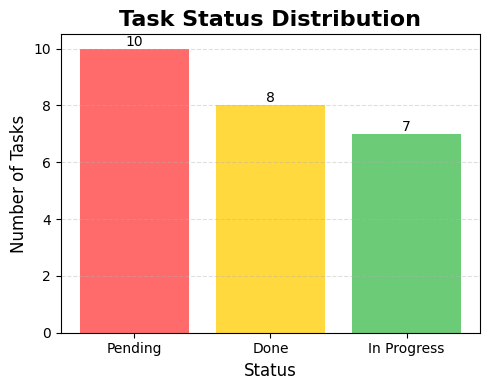

In [53]:
s_counts = df['status'].value_counts()
plt.figure(figsize=(5,4))

bars = plt.bar(s_counts.index,
               s_counts.values,
               color = ['#FF6B6B', '#FFD93D', '#6BCB77'])

plt.title("Task Status Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Status", fontsize=12)
plt.ylabel("Number of Tasks", fontsize=12)
    
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval,
             int(yval),
             ha='center',
             va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

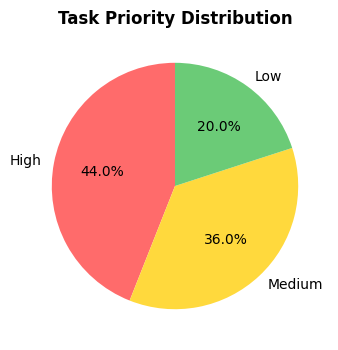

In [54]:
p_counts=df['priority'].value_counts()
plt.figure(figsize=(5,4))

plt.pie(p_counts.values,
        labels=p_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#FF6B6B', '#FFD93D', '#6BCB77']
)
plt.title("Task Priority Distribution", fontweight='bold' )
        
plt.show()

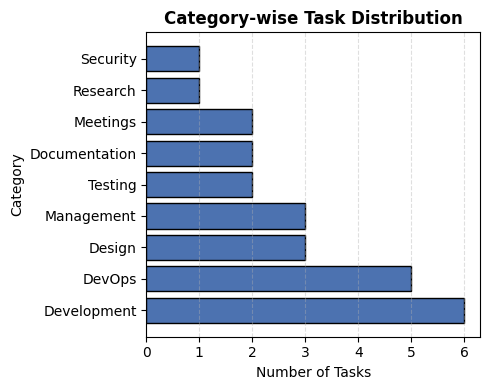

In [55]:
c_counts=df['category'].value_counts()
plt.figure(figsize=(5,4))

plt.barh(c_counts.index,
         c_counts.values , 
         color='#4C72B0',
         edgecolor='black')

plt.title("Category-wise Task Distribution", fontweight='bold')
plt.xlabel("Number of Tasks")
plt.ylabel("Category")


plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

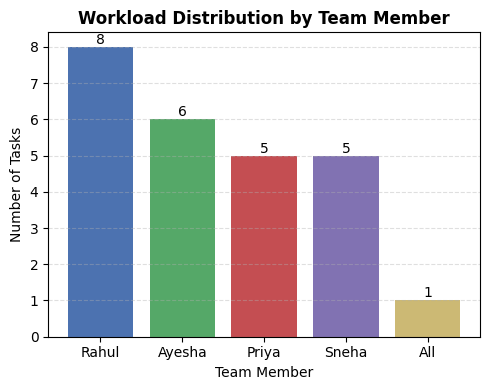

In [56]:
workload = df['assigned_to'].value_counts()

plt.figure(figsize=(5,4))

bars = plt.bar(workload.index,
               workload.values,
               color = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974'])

plt.title("Workload Distribution by Team Member", fontweight='bold')
plt.xlabel("Team Member")
plt.ylabel("Number of Tasks")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval,
             int(yval),
             ha='center',
             va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Key Insights
- Most tasks are still pending.
- High priority tasks are more in number.
- Rahul has the most tasks.
- Some tasks take more time than expected.
- Development tasks are the highest.